In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better looking plots
sns.set_style("whitegrid")

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load the e-commerce fraud dataset
df_fraud = pd.read_csv('../data/raw/Fraud_Data.csv')

# Check what we loaded
print(f"Dataset shape: {df_fraud.shape}")
print(f"\nFirst 5 rows:")
df_fraud.head()

Dataset shape: (151112, 11)

First 5 rows:


,user_id,signup_time,purchase_time,purchase_value,device_id,source,browser,sex,age,ip_address,class
0,22058,2015-02-24 22:55:49,2015-04-18 02:47:11,34,QVPSPJUOCKZAR,SEO,Chrome,M,39,7.327584e+08,0
1,333320,2015-06-07 20:39:50,2015-06-08 01:38:54,16,EOGFQPIZPYXFZ,Ads,Chrome,F,53,3.503114e+08,0
2,1359,2015-01-01 18:52:44,2015-01-01 18:52:45,15,YSSKYOSJHPPLJ,SEO,Opera,M,53,2.621474e+09,1
3,150084,2015-04-28 21:13:25,2015-05-04 13:54:50,44,ATGTXKYKUDUQN,SEO,Safari,M,41,3.840542e+09,0
4,221365,2015-07-21 07:09:52,2015-09-09 18:40:53,39,NAUITBZFJKHWW,Ads,Safari,M,45,4.155831e+08,0


In [3]:
# Basic info about the dataset
df_fraud.info()

<class 'pandas.DataFrame'>
RangeIndex: 151112 entries, 0 to 151111
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   user_id         151112 non-null  int64  
 1   signup_time     151112 non-null  str    
 2   purchase_time   151112 non-null  str    
 3   purchase_value  151112 non-null  int64  
 4   device_id       151112 non-null  str    
 5   source          151112 non-null  str    
 6   browser         151112 non-null  str    
 7   sex             151112 non-null  str    
 8   age             151112 non-null  int64  
 9   ip_address      151112 non-null  float64
 10  class           151112 non-null  int64  
dtypes: float64(1), int64(4), str(6)
memory usage: 12.7 MB


Class Distribution:
class
0    136961
1     14151
Name: count, dtype: int64

Percentage:
class
0    90.635423
1     9.364577
Name: proportion, dtype: float64


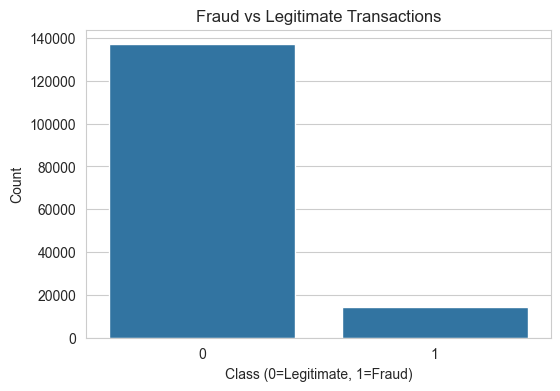

In [4]:
# Check distribution of fraud vs legitimate
print("Class Distribution:")
print(df_fraud['class'].value_counts())
print(f"\nPercentage:")
print(df_fraud['class'].value_counts(normalize=True) * 100)

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(data=df_fraud, x='class')
plt.title('Fraud vs Legitimate Transactions')
plt.xlabel('Class (0=Legitimate, 1=Fraud)')
plt.ylabel('Count')
plt.show()

In [5]:
# Check for missing values
print("Missing values per column:")
print(df_fraud.isnull().sum())

Missing values per column:
user_id           0
signup_time       0
purchase_time     0
purchase_value    0
device_id         0
source            0
browser           0
sex               0
age               0
ip_address        0
class             0
dtype: int64


In [6]:
# Summary statistics
df_fraud.describe()

,user_id,purchase_value,age,ip_address,class
count,151112.000000,151112.000000,151112.000000,1.511120e+05,151112.000000
mean,200171.040970,36.935372,33.140704,2.152145e+09,0.093646
std,115369.285024,18.322762,8.617733,1.248497e+09,0.291336
min,2.000000,9.000000,18.000000,5.209350e+04,0.000000
25%,100642.500000,22.000000,27.000000,1.085934e+09,0.000000
50%,199958.000000,35.000000,33.000000,2.154770e+09,0.000000
75%,300054.000000,49.000000,39.000000,3.243258e+09,0.000000
max,400000.000000,154.000000,76.000000,4.294850e+09,1.000000


In [7]:
# Look at categorical columns
categorical_cols = ['source', 'browser', 'sex']
for col in categorical_cols:
    print(f"\n{col.upper()} - Unique values:")
    print(df_fraud[col].value_counts())


SOURCE - Unique values:
source
SEO       60615
Ads       59881
Direct    30616
Name: count, dtype: int64

BROWSER - Unique values:
browser
Chrome     61432
IE         36727
Safari     24667
FireFox    24610
Opera       3676
Name: count, dtype: int64

SEX - Unique values:
sex
M    88293
F    62819
Name: count, dtype: int64


Fraud Rate by Source:
source
Direct    10.536974
Ads        9.206593
SEO        8.928483
Name: class, dtype: float64


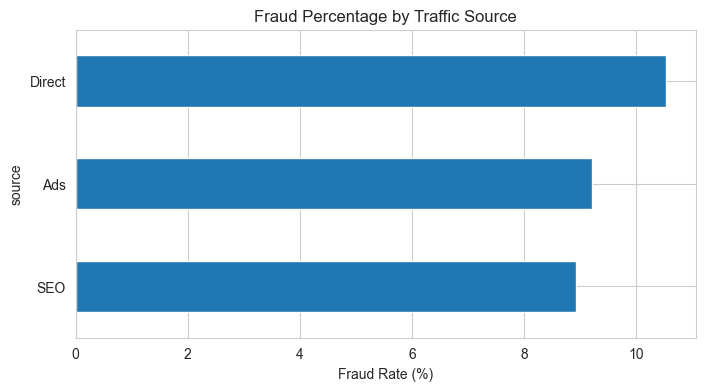

In [8]:
# Fraud rate by source
print("Fraud Rate by Source:")
fraud_by_source = df_fraud.groupby('source')['class'].mean() * 100
print(fraud_by_source.sort_values(ascending=False))

# Visualize
plt.figure(figsize=(8,4))
fraud_by_source.sort_values().plot(kind='barh')
plt.xlabel('Fraud Rate (%)')
plt.title('Fraud Percentage by Traffic Source')
plt.show()

Fraud Rate by Browser:
browser
Chrome     9.879216
FireFox    9.516457
Safari     9.020148
Opera      8.922742
IE         8.677540
Name: class, dtype: float64


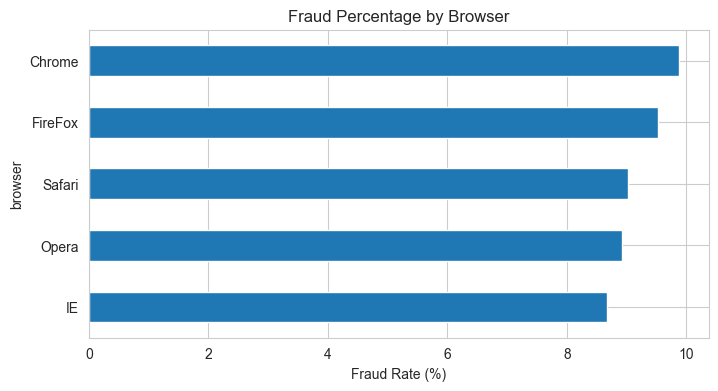

In [9]:
# Fraud rate by browser
print("Fraud Rate by Browser:")
fraud_by_browser = df_fraud.groupby('browser')['class'].mean() * 100
print(fraud_by_browser.sort_values(ascending=False))

plt.figure(figsize=(8,4))
fraud_by_browser.sort_values().plot(kind='barh')
plt.xlabel('Fraud Rate (%)')
plt.title('Fraud Percentage by Browser')
plt.show()

Fraud Rate by Sex:
sex
F    9.100750
M    9.552286
Name: class, dtype: float64


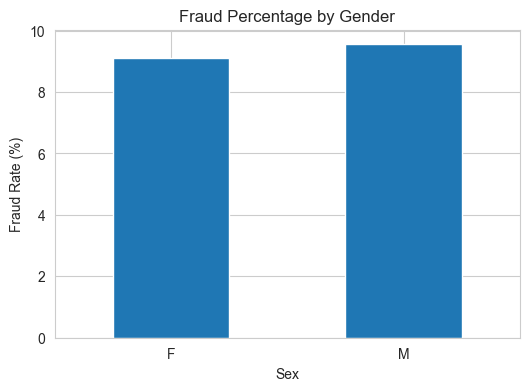

In [10]:
# Fraud rate by sex
print("Fraud Rate by Sex:")
fraud_by_sex = df_fraud.groupby('sex')['class'].mean() * 100
print(fraud_by_sex)

plt.figure(figsize=(6,4))
fraud_by_sex.plot(kind='bar')
plt.xlabel('Sex')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Percentage by Gender')
plt.xticks(rotation=0)
plt.show()

In [11]:
# Convert time columns to datetime
df_fraud['signup_time'] = pd.to_datetime(df_fraud['signup_time'])
df_fraud['purchase_time'] = pd.to_datetime(df_fraud['purchase_time'])

# Verify conversion
print(f"signup_time type: {df_fraud['signup_time'].dtype}")
print(f"purchase_time type: {df_fraud['purchase_time'].dtype}")

# Check the date range
print(f"\nSignup date range: {df_fraud['signup_time'].min()} to {df_fraud['signup_time'].max()}")
print(f"Purchase date range: {df_fraud['purchase_time'].min()} to {df_fraud['purchase_time'].max()}")

signup_time type: datetime64[us]
purchase_time type: datetime64[us]

Signup date range: 2015-01-01 00:00:42 to 2015-08-18 04:40:29
Purchase date range: 2015-01-01 00:00:44 to 2015-12-16 02:56:05


Time since signup statistics (hours):
count    151112.000000
mean       1370.008125
std         868.406422
min           0.000278
25%         607.431528
50%        1368.429306
75%        2123.479028
max        2879.992222
Name: time_since_signup_hours, dtype: float64

Average time since signup by class:
class
0    1441.994052
1     673.289542
Name: time_since_signup_hours, dtype: float64


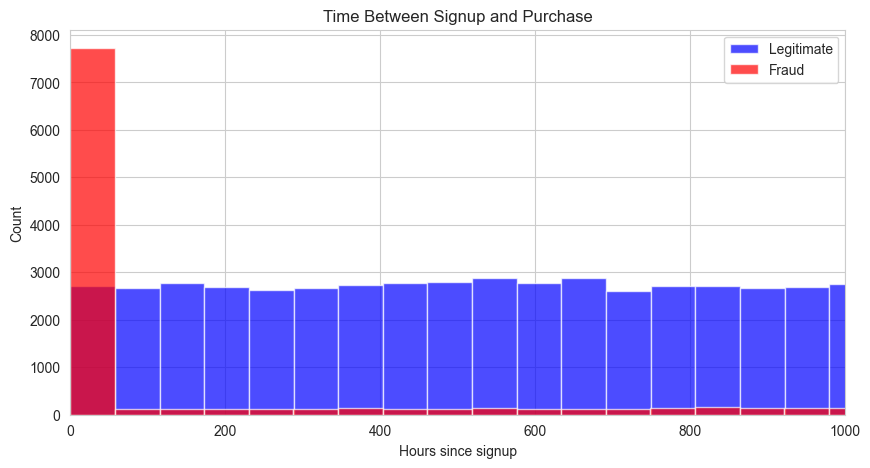

In [12]:
# Calculate time difference in hours
df_fraud['time_since_signup_hours'] = (df_fraud['purchase_time'] - df_fraud['signup_time']).dt.total_seconds() / 3600

# Check the results
print("Time since signup statistics (hours):")
print(df_fraud['time_since_signup_hours'].describe())

# Look at fraud vs legitimate
print("\nAverage time since signup by class:")
print(df_fraud.groupby('class')['time_since_signup_hours'].mean())

# Visualize
plt.figure(figsize=(10,5))
plt.hist(df_fraud[df_fraud['class']==0]['time_since_signup_hours'], bins=50, alpha=0.7, label='Legitimate', color='blue')
plt.hist(df_fraud[df_fraud['class']==1]['time_since_signup_hours'], bins=50, alpha=0.7, label='Fraud', color='red')
plt.xlabel('Hours since signup')
plt.ylabel('Count')
plt.title('Time Between Signup and Purchase')
plt.legend()
plt.xlim(0, 1000)  # Focus on first 1000 hours
plt.show()

In [13]:
# Look at transactions that happen within 1 hour of signup
very_quick = df_fraud[df_fraud['time_since_signup_hours'] < 1]
print(f"Transactions within 1 hour of signup: {len(very_quick)}")
print(f"Fraud rate in this group: {very_quick['class'].mean() * 100:.2f}%")

# Look at transactions within 24 hours
quick_24h = df_fraud[df_fraud['time_since_signup_hours'] < 24]
print(f"\nTransactions within 24 hours of signup: {len(quick_24h)}")
print(f"Fraud rate in this group: {quick_24h['class'].mean() * 100:.2f}%")

Transactions within 1 hour of signup: 7641
Fraud rate in this group: 99.52%

Transactions within 24 hours of signup: 8758
Fraud rate in this group: 87.33%


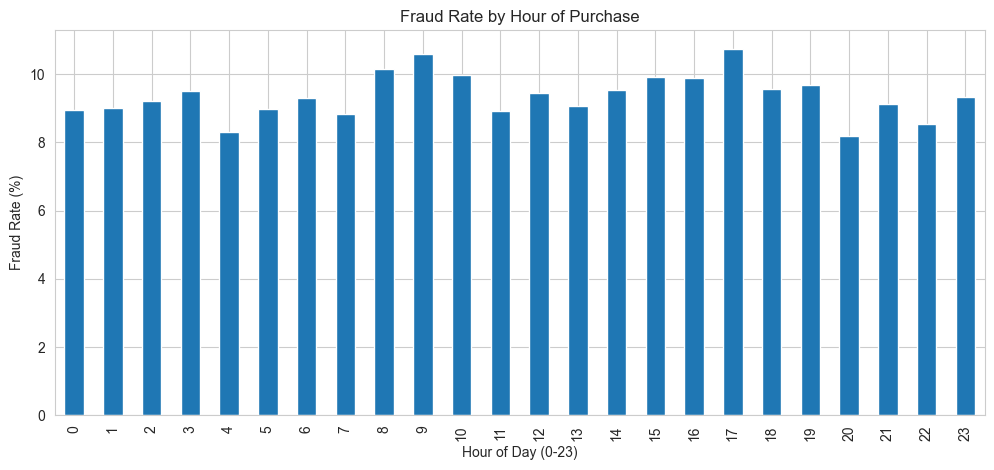

Highest fraud rate hours:
purchase_hour
17    10.748531
9     10.579620
8     10.145608
10     9.967213
15     9.907364
Name: class, dtype: float64


In [14]:
# Extract hour of day from purchase time
df_fraud['purchase_hour'] = df_fraud['purchase_time'].dt.hour

# Fraud rate by hour
fraud_by_hour = df_fraud.groupby('purchase_hour')['class'].mean() * 100

plt.figure(figsize=(12,5))
fraud_by_hour.plot(kind='bar')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Hour of Purchase')
plt.show()

print("Highest fraud rate hours:")
print(fraud_by_hour.nlargest(5))

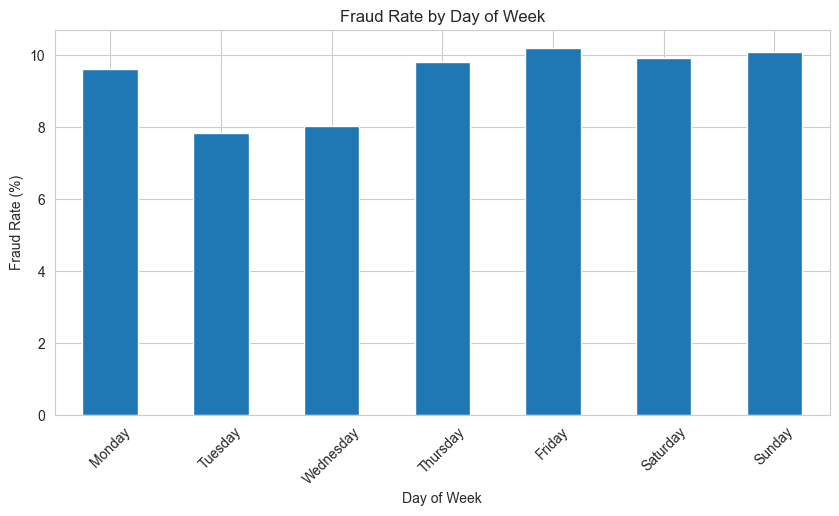

Fraud rate by day:
Monday: 9.62%
Tuesday: 7.83%
Wednesday: 8.03%
Thursday: 9.82%
Friday: 10.18%
Saturday: 9.93%
Sunday: 10.09%


In [15]:
# Extract day of week
df_fraud['purchase_dayofweek'] = df_fraud['purchase_time'].dt.dayofweek
# 0=Monday, 6=Sunday

fraud_by_day = df_fraud.groupby('purchase_dayofweek')['class'].mean() * 100

days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(10,5))
fraud_by_day.plot(kind='bar')
plt.xticks(range(7), days, rotation=45)
plt.xlabel('Day of Week')
plt.ylabel('Fraud Rate (%)')
plt.title('Fraud Rate by Day of Week')
plt.show()

print("Fraud rate by day:")
for i, day in enumerate(days):
    print(f"{day}: {fraud_by_day.iloc[i]:.2f}%")

In [16]:
# Save the dataframe with new features so far
df_fraud.to_csv('../data/processed/fraud_data_with_time_features.csv', index=False)
print("Data saved with time features!")

Data saved with time features!


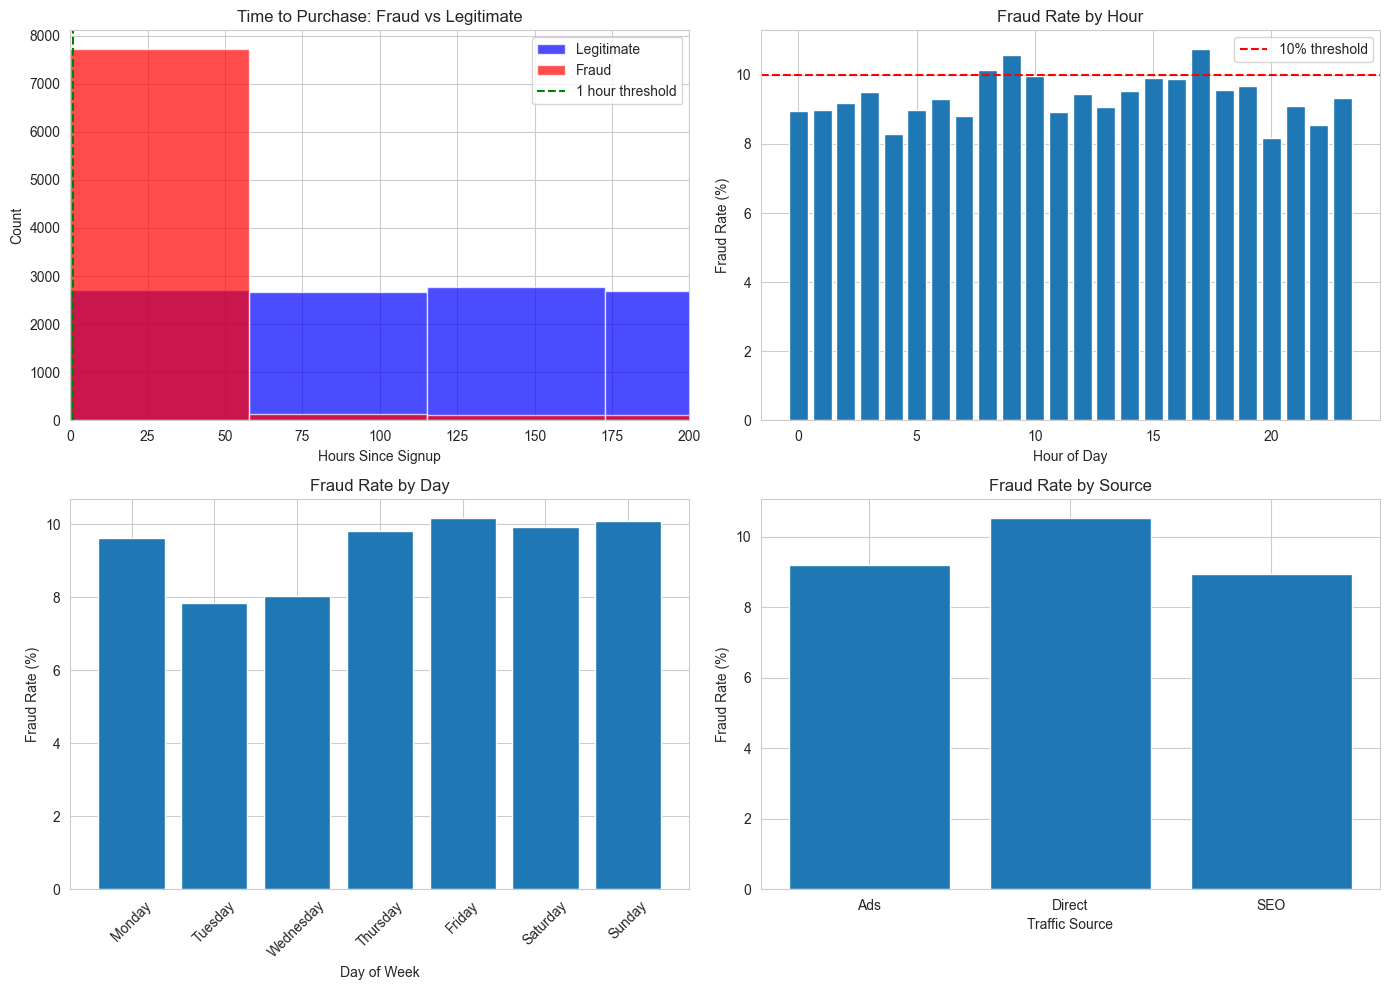

Dashboard saved!


In [17]:
# Create a fraud insights summary
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Time since signup (log scale to see pattern)
axes[0,0].hist(df_fraud[df_fraud['class']==0]['time_since_signup_hours'], 
               bins=50, alpha=0.7, label='Legitimate', color='blue')
axes[0,0].hist(df_fraud[df_fraud['class']==1]['time_since_signup_hours'], 
               bins=50, alpha=0.7, label='Fraud', color='red')
axes[0,0].set_xlabel('Hours Since Signup')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Time to Purchase: Fraud vs Legitimate')
axes[0,0].set_xlim(0, 200)
axes[0,0].legend()
axes[0,0].axvline(x=1, color='green', linestyle='--', label='1 hour threshold')
axes[0,0].legend()

# 2. Fraud rate by hour
axes[0,1].bar(fraud_by_hour.index, fraud_by_hour.values)
axes[0,1].set_xlabel('Hour of Day')
axes[0,1].set_ylabel('Fraud Rate (%)')
axes[0,1].set_title('Fraud Rate by Hour')
axes[0,1].axhline(y=10, color='red', linestyle='--', label='10% threshold')
axes[0,1].legend()

# 3. Fraud rate by day
axes[1,0].bar(days, fraud_by_day.values)
axes[1,0].set_xlabel('Day of Week')
axes[1,0].set_ylabel('Fraud Rate (%)')
axes[1,0].set_title('Fraud Rate by Day')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Fraud rate by source
source_fraud = df_fraud.groupby('source')['class'].mean() * 100
axes[1,1].bar(source_fraud.index, source_fraud.values)
axes[1,1].set_xlabel('Traffic Source')
axes[1,1].set_ylabel('Fraud Rate (%)')
axes[1,1].set_title('Fraud Rate by Source')

plt.tight_layout()
plt.savefig('../models/fraud_insights_dashboard.png')
plt.show()

print("Dashboard saved!")

In [18]:
# Load IP to Country data
ip_country = pd.read_csv('../data/raw/IpAddress_to_Country.csv')
print(f"IP Country mapping shape: {ip_country.shape}")
ip_country.head()

IP Country mapping shape: (138846, 3)


,lower_bound_ip_address,upper_bound_ip_address,country
0,16777216.0,16777471,Australia
1,16777472.0,16777727,China
2,16777728.0,16778239,China
3,16778240.0,16779263,Australia
4,16779264.0,16781311,China


In [19]:
# Check IP data structure
ip_country.info()

<class 'pandas.DataFrame'>
RangeIndex: 138846 entries, 0 to 138845
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   lower_bound_ip_address  138846 non-null  float64
 1   upper_bound_ip_address  138846 non-null  int64  
 2   country                 138846 non-null  str    
dtypes: float64(1), int64(1), str(1)
memory usage: 3.2 MB


In [20]:
# Convert IP addresses to integers for merging
def ip_to_int(ip):
    """Convert IP address string to integer"""
    parts = ip.split('.')
    return (int(parts[0]) << 24) + (int(parts[1]) << 16) + (int(parts[2]) << 8) + int(parts[3])

# Apply to fraud data (ip_address is already integer in your data!)
print(f"IP address type: {df_fraud['ip_address'].dtype}")
print(f"Sample IP as integer: {df_fraud['ip_address'].iloc[0]}")

IP address type: float64
Sample IP as integer: 732758368.79972


In [21]:
# Check unique IP address values to understand the issue
print("Sample of raw IP addresses:")
print(df_fraud['ip_address'].head(10))
print(f"\nData type: {df_fraud['ip_address'].dtype}")

Sample of raw IP addresses:
0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
5    2.809315e+09
6    3.987484e+09
7    1.692459e+09
8    3.719094e+09
9    3.416747e+08
Name: ip_address, dtype: float64

Data type: float64


In [22]:
# Convert IP to integer (remove decimals by rounding or converting)
# IP addresses should be integers, so we'll round them
df_fraud['ip_address_clean'] = df_fraud['ip_address'].round().astype('int64')

# Verify
print("Cleaned IP addresses:")
print(df_fraud['ip_address_clean'].head(10))
print(f"New data type: {df_fraud['ip_address_clean'].dtype}")

Cleaned IP addresses:
0     732758369
1     350311388
2    2621473820
3    3840542444
4     415583117
5    2809315200
6    3987484329
7    1692458728
8    3719094257
9     341674740
Name: ip_address_clean, dtype: int64
New data type: int64


In [23]:
# Sort IP country data for merge_asof (requires sorting)
ip_country_sorted = ip_country.sort_values('lower_bound_ip_address')

# Ensure the bound columns are integers
ip_country_sorted['lower_bound_ip_address'] = ip_country_sorted['lower_bound_ip_address'].astype('int64')
ip_country_sorted['upper_bound_ip_address'] = ip_country_sorted['upper_bound_ip_address'].astype('int64')

# Prepare fraud data for merge
fraud_for_merge = df_fraud.sort_values('ip_address_clean')

# Perform range-based merge
# This matches each IP to the row where lower_bound <= IP <= upper_bound
df_fraud_with_country = pd.merge_asof(
    fraud_for_merge,
    ip_country_sorted,
    left_on='ip_address_clean',
    right_on='lower_bound_ip_address',
    direction='backward'
)

# Now filter to ensure IP is within upper bound as well
df_fraud_with_country = df_fraud_with_country[
    df_fraud_with_country['ip_address_clean'] <= df_fraud_with_country['upper_bound_ip_address']
]

print(f"Matched {len(df_fraud_with_country)} out of {len(df_fraud)} records")

Matched 129146 out of 151112 records


In [24]:
# Check fraud rate by country
country_fraud = df_fraud_with_country.groupby('country')['class'].agg(['count', 'mean'])
country_fraud['fraud_rate_pct'] = country_fraud['mean'] * 100
country_fraud.columns = ['total_transactions', 'fraud_rate', 'fraud_rate_pct']

# Top 10 countries with highest fraud rate (minimum 100 transactions to avoid noise)
country_fraud_filtered = country_fraud[country_fraud['total_transactions'] >= 100]
top_fraud_countries = country_fraud_filtered.sort_values('fraud_rate_pct', ascending=False).head(10)

print("Top 10 Countries with Highest Fraud Rate:")
print(top_fraud_countries[['total_transactions', 'fraud_rate_pct']])

Top 10 Countries with Highest Fraud Rate:
                      total_transactions  fraud_rate_pct
country                                                 
Ecuador                              106       26.415094
Tunisia                              118       26.271186
Peru                                 119       26.050420
Ireland                              240       22.916667
New Zealand                          278       22.302158
Saudi Arabia                         264       18.939394
Denmark                              490       15.918367
Chile                                417       15.347722
Greece                               231       14.285714
United Arab Emirates                 114       14.035088


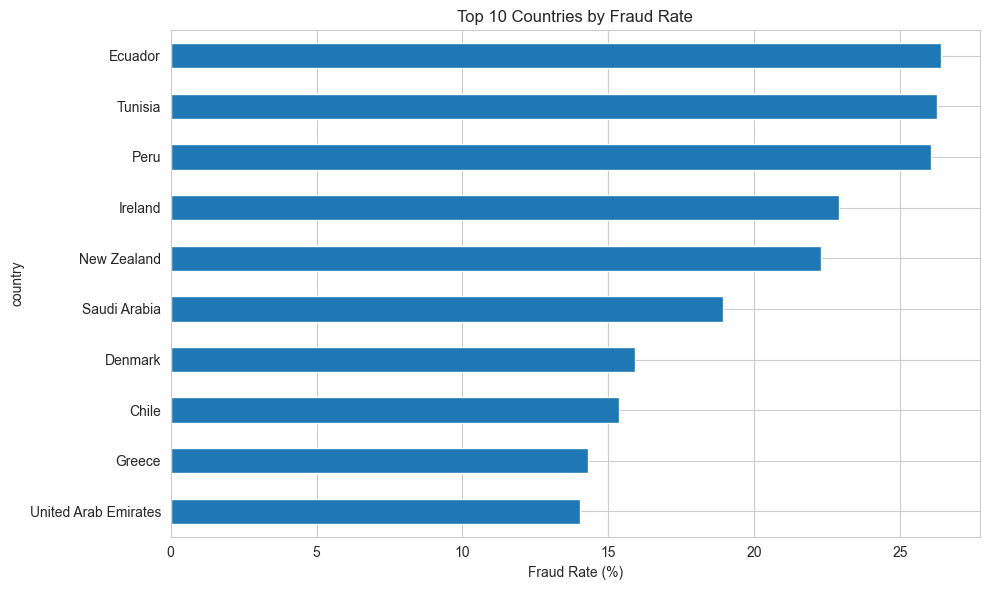

In [25]:
# Visualize top fraud countries
plt.figure(figsize=(10,6))
top_fraud_countries['fraud_rate_pct'].sort_values().plot(kind='barh')
plt.xlabel('Fraud Rate (%)')
plt.title('Top 10 Countries by Fraud Rate')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

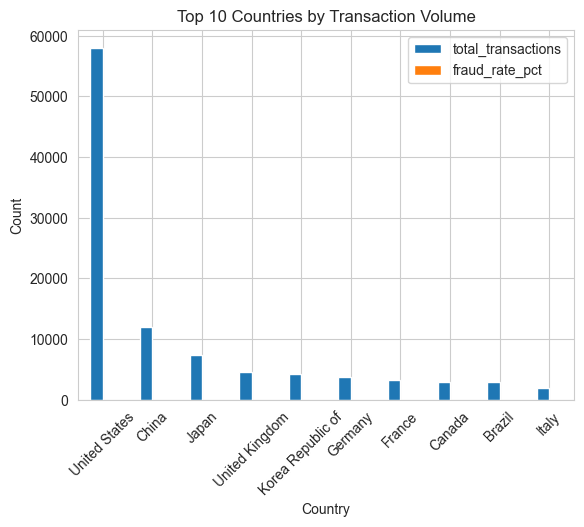

Top countries by fraud volume:
                   total_transactions  fraud_rate_pct
country                                              
United States                   58049        9.562611
China                           12038        8.664230
Japan                            7306        9.786477
United Kingdom                   4490       10.623608
Korea Republic of                4162        9.130226
Germany                          3646        7.185957
France                           3161        9.490668
Canada                           2975       11.697479
Brazil                           2961        9.118541
Italy                            1944        8.539095


In [26]:
# Countries with most fraud cases (volume)
top_volume_countries = country_fraud_filtered.sort_values('total_transactions', ascending=False).head(10)

plt.figure(figsize=(10,6))
top_volume_countries[['total_transactions', 'fraud_rate_pct']].plot(kind='bar')
plt.xlabel('Country')
plt.ylabel('Count')
plt.title('Top 10 Countries by Transaction Volume')
plt.xticks(rotation=45)
plt.show()

print("Top countries by fraud volume:")
print(top_volume_countries[['total_transactions', 'fraud_rate_pct']])

In [27]:
# Save the dataframe with country information
df_fraud_with_country.to_csv('../data/processed/fraud_data_with_country.csv', index=False)
print("Saved fraud data with country information!")
print(f"Final dataset shape: {df_fraud_with_country.shape}")

Saved fraud data with country information!
Final dataset shape: (129146, 18)
